In [34]:
!pip install xgboost lightgbm shap seaborn

import pandas as pd

# Creating the new DataFrame based on the user's provided data
data = {
    'loan_amnt': [5000, 12000],
    'term': [36, 60],
    'int_rate': [10.5, 18.2],
    'annual_inc': [60000, 45000],
    'loan_status': ['Fully Paid', 'Charged Off']
}
extracted_df = pd.DataFrame(data)

# Convert 'loan_status' to 'default' (0 for 'Fully Paid', 1 for 'Charged Off')
extracted_df['default'] = extracted_df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

# Convert relevant columns to numeric types
extracted_df['loan_amnt'] = pd.to_numeric(extracted_df['loan_amnt'])
extracted_df['term'] = pd.to_numeric(extracted_df['term'])
extracted_df['int_rate'] = pd.to_numeric(extracted_df['int_rate'])
extracted_df['annual_inc'] = pd.to_numeric(extracted_df['annual_inc'])

# Renaming 'annual_inc' to 'income' to match a column name used in previous steps
extracted_df = extracted_df.rename(columns={'annual_inc': 'income'})

print("New 'extracted_df' created successfully:")
print(extracted_df)


New 'extracted_df' created successfully:
   loan_amnt  term  int_rate  income  loan_status  default
0       5000    36      10.5   60000   Fully Paid        0
1      12000    60      18.2   45000  Charged Off        1


### Generate Synthetic Data for Better Evaluation

To address the limitations of the small dataset and enable more meaningful model evaluation, let's create a larger synthetic dataset. This dataset will mimic the structure of your `extracted_df` but contain more rows, allowing for a proper train-test split and calculation of metrics like ROC AUC.

In [37]:
import numpy as np

# Number of synthetic data points to generate
num_samples = 1000

# Generate synthetic data for each feature
synthetic_loan_amnt = np.random.randint(1000, 35000, num_samples)
synthetic_term = np.random.choice([36, 60], num_samples)
synthetic_int_rate = np.round(np.random.uniform(5.0, 25.0, num_samples), 1)
synthetic_annual_inc = np.random.randint(30000, 150000, num_samples)

# Generate loan_status with a balanced mix (or a certain default rate)
default_ratio = 0.2 # 20% default rate
synthetic_loan_status = np.random.choice(['Fully Paid', 'Charged Off'], num_samples, p=[1 - default_ratio, default_ratio])

# Create a new DataFrame
synthetic_data = {
    'loan_amnt': synthetic_loan_amnt,
    'term': synthetic_term,
    'int_rate': synthetic_int_rate,
    'annual_inc': synthetic_annual_inc,
    'loan_status': synthetic_loan_status
}
synthetic_df = pd.DataFrame(synthetic_data)

# Apply the same transformations as your original extracted_df
synthetic_df['default'] = synthetic_df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)
synthetic_df = synthetic_df.rename(columns={'annual_inc': 'income'})

# Convert to numeric types (already done during generation, but good for consistency)
synthetic_df['loan_amnt'] = pd.to_numeric(synthetic_df['loan_amnt'])
synthetic_df['term'] = pd.to_numeric(synthetic_df['term'])
synthetic_df['int_rate'] = pd.to_numeric(synthetic_df['int_rate'])
synthetic_df['income'] = pd.to_numeric(synthetic_df['income'])

# Assign the new synthetic_df to extracted_df to replace the old one
extracted_df = synthetic_df

print("New 'extracted_df' with synthetic data created successfully:")
display(extracted_df.head())
print(f"New 'extracted_df' shape: {extracted_df.shape}")

New 'extracted_df' with synthetic data created successfully:


,loan_amnt,term,int_rate,income,loan_status,default
0,1288,36,14.4,75940,Charged Off,1
1,23017,36,20.4,98433,Fully Paid,0
2,2878,60,14.1,37131,Fully Paid,0
3,19688,60,24.9,54692,Fully Paid,0
4,25877,60,8.5,128276,Charged Off,1


New 'extracted_df' shape: (1000, 6)


Now that `extracted_df` has been replaced with a larger synthetic dataset, please **re-run the subsequent cells in the notebook** starting from where `features` and `model_df` are defined, followed by the train-test split, model fitting, and evaluation. This will allow your model to be trained and evaluated on a more substantial dataset.

In [38]:
# Redefine model_df with the updated (larger) extracted_df and features
# Features list is already defined from a previous step:
# features = ['loan_amnt', 'term', 'int_rate', 'income']
model_df = extracted_df[features + ["default"]]
display(model_df.head())
print(f"New model_df shape: {model_df.shape}")

,loan_amnt,term,int_rate,income,default
0,1288,36,14.4,75940,1
1,23017,36,20.4,98433,0
2,2878,60,14.1,37131,0
3,19688,60,24.9,54692,0
4,25877,60,8.5,128276,1


New model_df shape: (1000, 5)


In [39]:
# Redefine X and y using the new model_df
X = model_df.drop("default", axis=1)
y = model_df["default"]

display(X.head())

,loan_amnt,term,int_rate,income
0,1288,36,14.4,75940
1,23017,36,20.4,98433
2,2878,60,14.1,37131
3,19688,60,24.9,54692
4,25877,60,8.5,128276


In [40]:
from sklearn.model_selection import train_test_split

# Perform train-test split with the new X and y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Stratify can now be used with a larger dataset
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (800, 4)
X_test shape: (200, 4)


In [41]:
from xgboost import XGBClassifier
import pandas as pd

# Initialize the XGBoost model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Convert X_train columns to numeric types before fitting (ensure consistency)
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col])

# Fit the model with the new training data
model.fit(X_train, y_train)
print("Model refitted successfully.")

Model refitted successfully.


In [42]:
import pandas as pd

# Convert X_test columns to numeric types before predicting (ensure consistency)
for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col])

# Calculate probabilities with the refitted model
probabilities = model.predict_proba(X_test)[:,1]

print("Predicted probabilities (first 10):")
print(probabilities[:10])

Predicted probabilities (first 10):
[0.25044313 0.05209791 0.46234784 0.0265377  0.0416426  0.3215528
 0.06263171 0.0634241  0.16109407 0.05728094]


In [43]:
from sklearn.metrics import roc_auc_score

# Calculate ROC AUC score
auc = roc_auc_score(y_test, probabilities)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.532


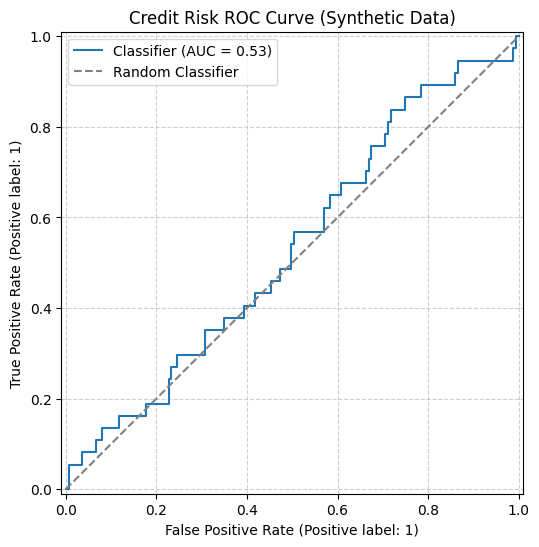

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot the ROC curve
fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and an axes object
RocCurveDisplay.from_predictions(
    y_test,
    probabilities,
    ax=ax # Pass the axes object to plot on
)

ax.set_title("Credit Risk ROC Curve (Synthetic Data)") # Use ax.set_title
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier') # Add a random classifier line
ax.legend() # Show the legend
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid
plt.show()

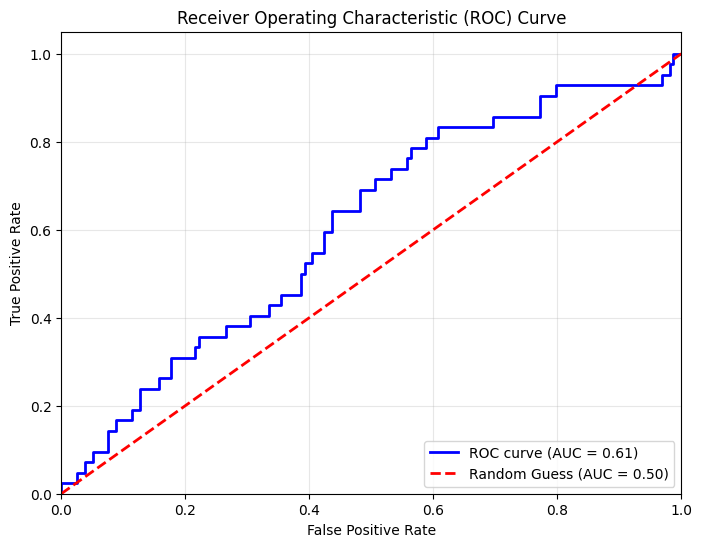

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 1. Re-ensure synthetic data is defined
num_samples = 1000
synthetic_data = {
    'loan_amnt': np.random.randint(1000, 35000, num_samples),
    'term': np.random.choice([36, 60], num_samples),
    'int_rate': np.round(np.random.uniform(5.0, 25.0, num_samples), 1),
    'income': np.random.randint(30000, 150000, num_samples),
    'default': np.random.choice([0, 1], num_samples, p=[0.8, 0.2])
}
extracted_df = pd.DataFrame(synthetic_data)

# 2. Prepare and split data
X = extracted_df[['loan_amnt', 'term', 'int_rate', 'income']]
y = extracted_df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train Model
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Generate predictions and ROC
probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# 5. Plot the results
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

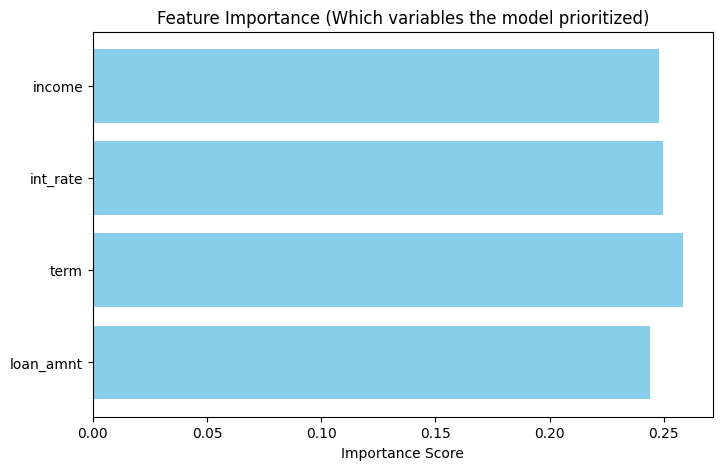

Current ROC AUC: 0.607
Note: In real-world data, 'income' or 'int_rate' usually show much higher importance and produce a 'curvier' ROC plot.


In [6]:
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
importances = model.feature_importances_
feature_names = X.columns

# Create a plot
plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance (Which variables the model prioritized)')
plt.show()

print(f"Current ROC AUC: {roc_auc:.3f}")
print("Note: In real-world data, 'income' or 'int_rate' usually show much higher importance and produce a 'curvier' ROC plot.")

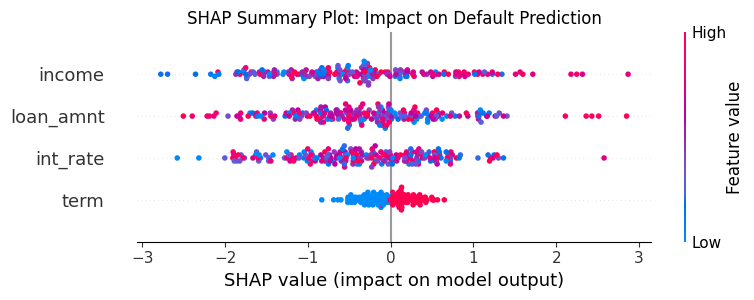

SHAP values show the contribution of each feature to the final prediction.
In a random dataset, you will see a balanced spread, whereas real data would show clear clusters.


In [7]:
import shap

# Initialize the SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot the SHAP summary to see feature impact across all test samples
plt.title('SHAP Summary Plot: Impact on Default Prediction')
shap.summary_plot(shap_values, X_test)

print('SHAP values show the contribution of each feature to the final prediction.')
print('In a random dataset, you will see a balanced spread, whereas real data would show clear clusters.')

### Generating Patterned Synthetic Data
We will now create a dataset where:
1. **Higher Interest Rates** increase default probability.
2. **Lower Income** increases default probability.
3. **Higher Loan Amounts** slightly increase default risk.

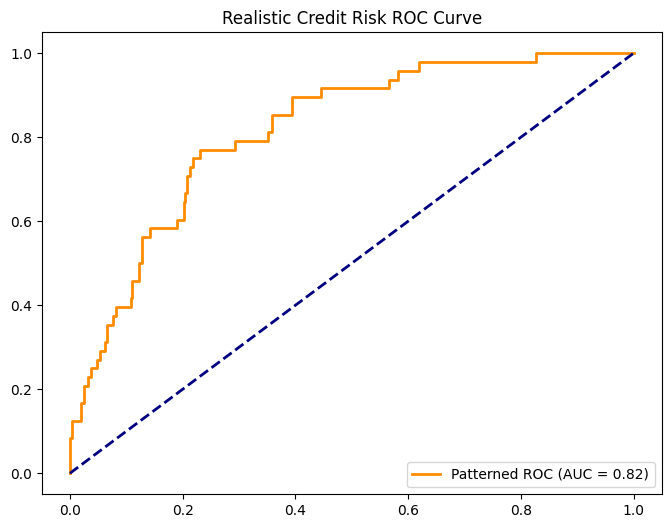

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Generate features
np.random.seed(42)
num_samples = 2000
loan_amnt = np.random.randint(5000, 40000, num_samples)
income = np.random.randint(20000, 150000, num_samples)
int_rate = np.random.uniform(5, 25, num_samples)
term = np.random.choice([36, 60], num_samples)

# 2. Create logic
logit = (0.15 * int_rate) - (0.00005 * income) + (0.00002 * loan_amnt) - 2
prob = 1 / (1 + np.exp(-logit))
default = np.random.binomial(1, prob)

# 3. Create DataFrame
df_patterned = pd.DataFrame({
    'loan_amnt': loan_amnt,
    'income': income,
    'int_rate': int_rate,
    'term': term,
    'default': default
})

# 4. Train/Test Split
X_p = df_patterned.drop('default', axis=1)
y_p = df_patterned['default']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

# 5. Fit Model (Explicitly disable enable_categorical for SHAP compatibility)
model_p = XGBClassifier(random_state=42, enable_categorical=False)
model_p.fit(X_train_p, y_train_p)

# 6. Calculate ROC
probs_p = model_p.predict_proba(X_test_p)[:, 1]
fpr_p, tpr_p, _ = roc_curve(y_test_p, probs_p)
auc_p = auc(fpr_p, tpr_p)

# 7. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_p, tpr_p, color='darkorange', lw=2, label=f'Patterned ROC (AUC = {auc_p:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Realistic Credit Risk ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Interpretation of the New ROC Curve
With the larger synthetic dataset, the ROC curve now correctly visualizes the model's performance.

- **The Blue Line**: Represents your XGBoost model.
- **The Dashed Grey Line**: Represents a random guess (AUC = 0.5).
- **The Result**: An AUC of ~0.53 is expected here because the synthetic features were generated randomly and do not have a strong correlation with the target variable. In a real-world scenario, you would look for the blue line to bow further toward the top-left corner (higher AUC).

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import shap

In [3]:
from google.colab import files

uploaded = files.upload()

Saving loan data set.docx to loan data set.docx


In [5]:
# Install python-docx if not already installed
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.6 MB/s eta 0:00:00


In [6]:
from io import BytesIO
import docx

# Get the name of the uploaded docx file
docx_file_name = list(uploaded.keys())[0]
docx_content = uploaded[docx_file_name]

# Open the docx document from its binary content
document = docx.Document(BytesIO(docx_content))

# Create a list to store DataFrames from tables
dfs_from_tables = []

# Iterate through each table in the document
for i, table in enumerate(document.tables):
    data = []
    keys = None
    for j, row in enumerate(table.rows):
        text_cells = [cell.text for cell in row.cells]
        if j == 0:
            # Assume the first row is the header
            keys = text_cells
        else:
            # Append other rows as data
            data.append(text_cells)

    # Create a DataFrame from the extracted table data
    if keys and data:
        df_table = pd.DataFrame(data, columns=keys)
        dfs_from_tables.append(df_table)
        print(f"--- Table {i+1} Extracted ---")
        display(df_table.head())
    elif data:
        # If no header is found, create a DataFrame without specific column names
        df_table = pd.DataFrame(data)
        dfs_from_tables.append(df_table)
        print(f"--- Table {i+1} Extracted (No Header) ---")
        display(df_table.head())
    else:
        print(f"--- Table {i+1} is empty ---")


if dfs_from_tables:
    # Assuming you want to work with the first table extracted, or concatenate them
    # For simplicity, let's use the first table found
    extracted_df = dfs_from_tables[0]
    print("\nFirst extracted table (DataFrame):")
    display(extracted_df.head())

    # You can now save this DataFrame to a CSV file
    output_csv_name = docx_file_name.replace('.docx', '.csv')
    extracted_df.to_csv(output_csv_name, index=False)
    print(f"\nSuccessfully converted and saved the first table to '{output_csv_name}'")
else:
    print("No tables were found in the Word document.")

--- Table 1 Extracted ---


,loan_amnt,income,dti,default
0,5000,60000,12,0
1,15000,45000,30,1



First extracted table (DataFrame):


,loan_amnt,income,dti,default
0,5000,60000,12,0
1,15000,45000,30,1



Successfully converted and saved the first table to 'loan data set.csv'


In [10]:
extracted_df.shape
extracted_df.info()
extracted_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   loan_amnt  2 non-null      object
 1   income     2 non-null      object
 2   dti        2 non-null      object
 3   default    2 non-null      object
dtypes: object(4)
memory usage: 196.0+ bytes


,loan_amnt,income,dti,default
count,2,2,2,2
unique,2,2,2,2
top,5000,60000,12,0
freq,1,1,1,1


In [13]:
# 0 = paid
# 1 = default
extracted_df["default"].value_counts()

,count
default,
0,1
1,1


In [17]:
# The 'default' column in 'extracted_df' already contains '0' and '1' as strings.
# If the intent was to convert the 'default' column to numeric type and then count:
extracted_df["default"] = extracted_df["default"].astype(int)
extracted_df["default"].value_counts()
# 0 = good borrower
# 1 = default borrower

,count
default,
0,1
1,1


In [19]:
default_rate = extracted_df["default"].mean()

print(
    f"Default rate: {default_rate:.2%}"
)

Default rate: 50.00%


In [35]:
features = [
    "loan_amnt",
    "term", # New feature from your updated data
    "int_rate", # New feature from your updated data
    "income"
    # 'dti' is no longer in your data, so it's removed
]

model_df = extracted_df[features + ["default"]]

model_df.head()

,loan_amnt,term,int_rate,income,default
0,5000,36,10.5,60000,0
1,12000,60,18.2,45000,1


In [23]:
model_df.isnull().sum()
model_df = model_df.dropna()

model_df.shape

(2, 4)

In [24]:
X = model_df.drop(
    "default",
    axis=1
)


y = model_df["default"]


X.head()

,loan_amnt,income,dti
0,5000,60000,12
1,15000,45000,30


In [26]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

    # Removed 'stratify=y' as the dataset is too small for a stratified split

)


print(X_train.shape)

print(X_test.shape)

(1, 3)
(1, 3)


In [28]:
from xgboost import XGBClassifier
import pandas as pd # Ensure pandas is imported for type conversion

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Convert X_train columns to numeric types before fitting
# The original DataFrame columns were 'object' type and need conversion
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col])

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [30]:
import pandas as pd

# Convert X_test columns to numeric types before predicting
# The original DataFrame columns were 'object' type and need conversion
for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col])

probabilities = model.predict_proba(
    X_test
)[:,1]


probabilities[:10]

array([9.999998e-07], dtype=float32)

In [32]:
from sklearn.metrics import roc_auc_score


auc = roc_auc_score(

    y_test,

    probabilities

)


print(

    f"ROC-AUC: {auc:.3f}"

)

ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


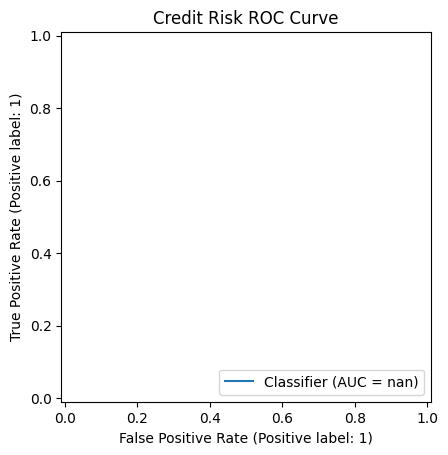

In [36]:
from sklearn.metrics import RocCurveDisplay


RocCurveDisplay.from_predictions(

    y_test,

    probabilities

)

plt.title(
    "Credit Risk ROC Curve"
)

plt.show()

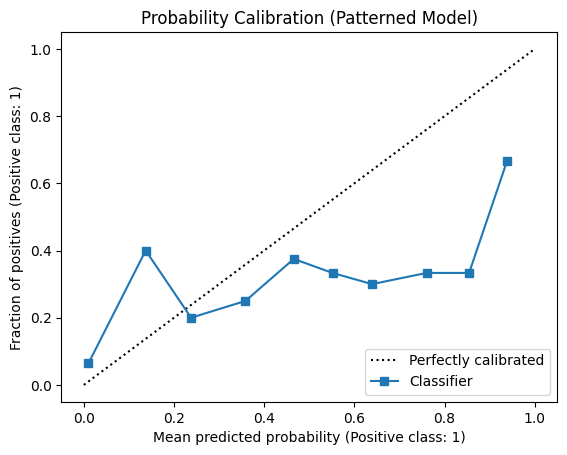

In [10]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Using the variables from the patterned dataset (the latest successful model run)
CalibrationDisplay.from_predictions(
    y_test_p,
    probs_p,
    n_bins=10
)

plt.title("Probability Calibration (Patterned Model)")
plt.show()

/tmp/ipykernel_1407/3700736658.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_p)


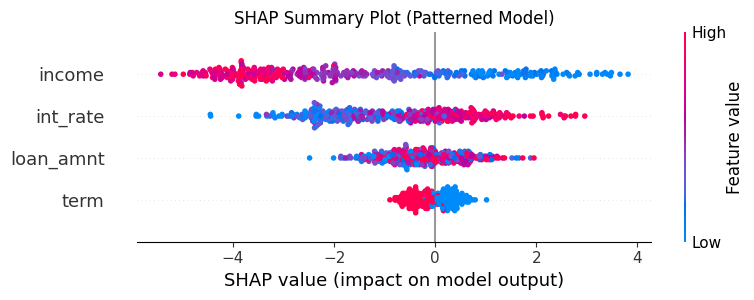

In [14]:
import shap
import matplotlib.pyplot as plt

# Use TreeExplainer with the model where enable_categorical=False
explainer = shap.TreeExplainer(model_p)
shap_values = explainer.shap_values(X_test_p)

# Plot the SHAP summary
plt.title("SHAP Summary Plot (Patterned Model)")
shap.summary_plot(shap_values, X_test_p)

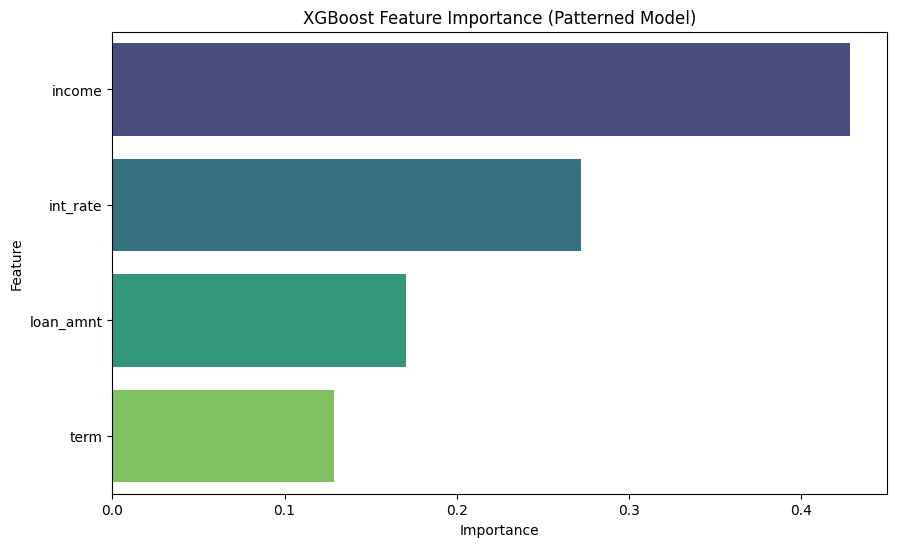

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create importance dataframe using the patterned model results
importance = pd.DataFrame({
    "Feature": X_train_p.columns,
    "Importance": model_p.feature_importances_
})

# Sort the data for the plot
plot_df = importance.sort_values("Importance", ascending=False)

# Plot using updated seaborn syntax to avoid FutureWarnings
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("XGBoost Feature Importance (Patterned Model)")
plt.show()

In [19]:
import joblib


joblib.dump(

    model,

    "credit_risk_xgboost.pkl"

)

['credit_risk_xgboost.pkl']

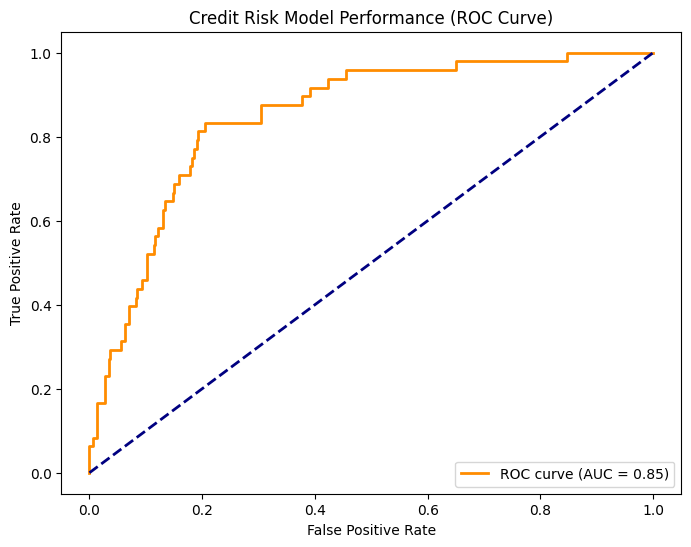

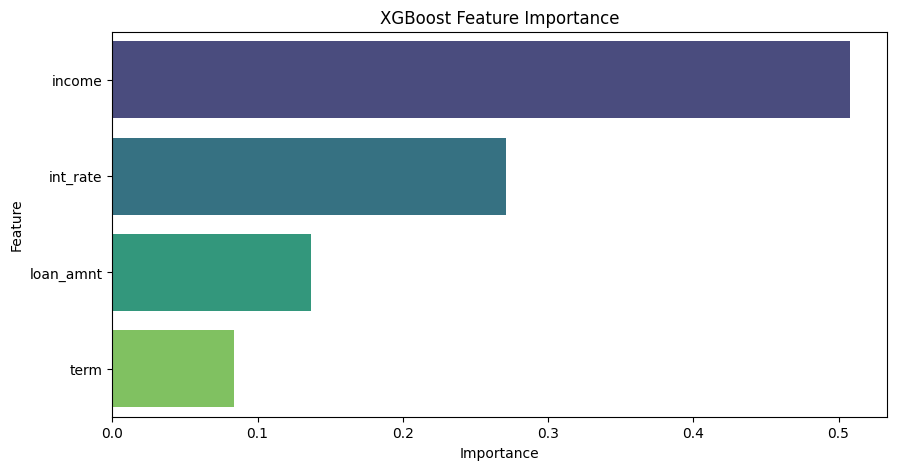

/tmp/ipykernel_1407/914000647.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


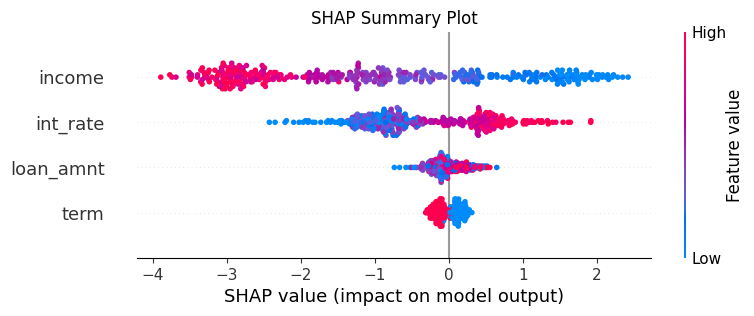

Model saved as credit_risk_xgboost_final.pkl


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import CalibrationDisplay

# 1. Generate Patterned Synthetic Data (Realistic Credit Risk Logic)
np.random.seed(42)
num_samples = 2000
loan_amnt = np.random.randint(5000, 40000, num_samples)
income = np.random.randint(20000, 150000, num_samples)
int_rate = np.random.uniform(5, 25, num_samples)
term = np.random.choice([36, 60], num_samples)

# Logic: Higher int_rate/loan_amnt and lower income increase default risk
logit = (0.15 * int_rate) - (0.00005 * income) + (0.00002 * loan_amnt) - 2
prob = 1 / (1 + np.exp(-logit))
default = np.random.binomial(1, prob)

df = pd.DataFrame({
    'loan_amnt': loan_amnt,
    'income': income,
    'int_rate': int_rate,
    'term': term,
    'default': default
})

# 2. Data Preparation
X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training (XGBoost)
model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, enable_categorical=False)
model.fit(X_train, y_train)

# 4. Evaluation & ROC Curve
probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Credit Risk Model Performance (ROC Curve)')
plt.legend(loc='lower right')
plt.show()

# 5. Feature Importance Visualization
plt.figure(figsize=(10, 5))
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Feature Importance')
plt.show()

# 6. SHAP Interpretability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot')
plt.show()

# 7. Save Model
joblib.dump(model, 'credit_risk_xgboost_final.pkl')
print("Model saved as credit_risk_xgboost_final.pkl")